In [33]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from SpaceBalls.postproc_EEI_estimation import check_EEI_consistency, get_full_output_var_hist, get_radial_measurement_arrays, get_jd_window_idxs, getnnz
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
from SpaceBalls.sph_meshing import get_sphere_grid, lonlat_to_r
from SpaceBalls.utils import latlon_to_coord_name
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR

import string
letters = string.ascii_lowercase

matplotlib.rcParams.update({

    # Font
    "font.size": 10,
    "font.family": "STIXGeneral",  # A clean, professional font
    "mathtext.fontset": "stix",

    # Axes
    "axes.linewidth": 0.8,
    "axes.labelsize": 10,
    "axes.titlesize": 10,

    # Lines
    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    # Ticks
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Legend
    "legend.fontsize": 9,
    "legend.frameon": False,

    # Grid (usually off in publications)
    "axes.grid": False,

    # Figure
    "figure.dpi": 150
})

def load_map_file(dir, map_name, n_lon, n_lat):
    try:
        map_hist = np.load(os.path.join(dir, map_name+'.npy'))
    except FileNotFoundError:
        map_hist = np.loadtxt(os.path.join(dir, map_name+'.txt')).reshape((n_lat, n_lon, -1))
    
    return map_hist



In [ ]:
sat_names = ['C2', 'D1', 'I2']
#sat_names = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'C1', 'C2', 'C3', 'D1', 'D2', 'D3', 
#                'E1', 'E2', 'E3', 'F1', 'F2', 'F3', 'F11', 'F12', 'G1', 'G2', 'G3', 'H1', 'H2', 'H3', 'I1', 'I2', 'I3']
input_names = ['case_5_years_sc_' + tag for tag in sat_names]
n_sat = len(input_names)
altitude = 800  # TODO: make robust and get from input database

n_lon_stacking, n_lat_stacking = 360, 180  # for now should be the same as for the truth
frame = 'SFF'
day_idx = 0

add_20km_bounds = True
add_side_bounds = True
add_offset_colors = True
add_avgs = True
correct_meas = False

#np.random.seed(4)  # for reproducibility of random choices

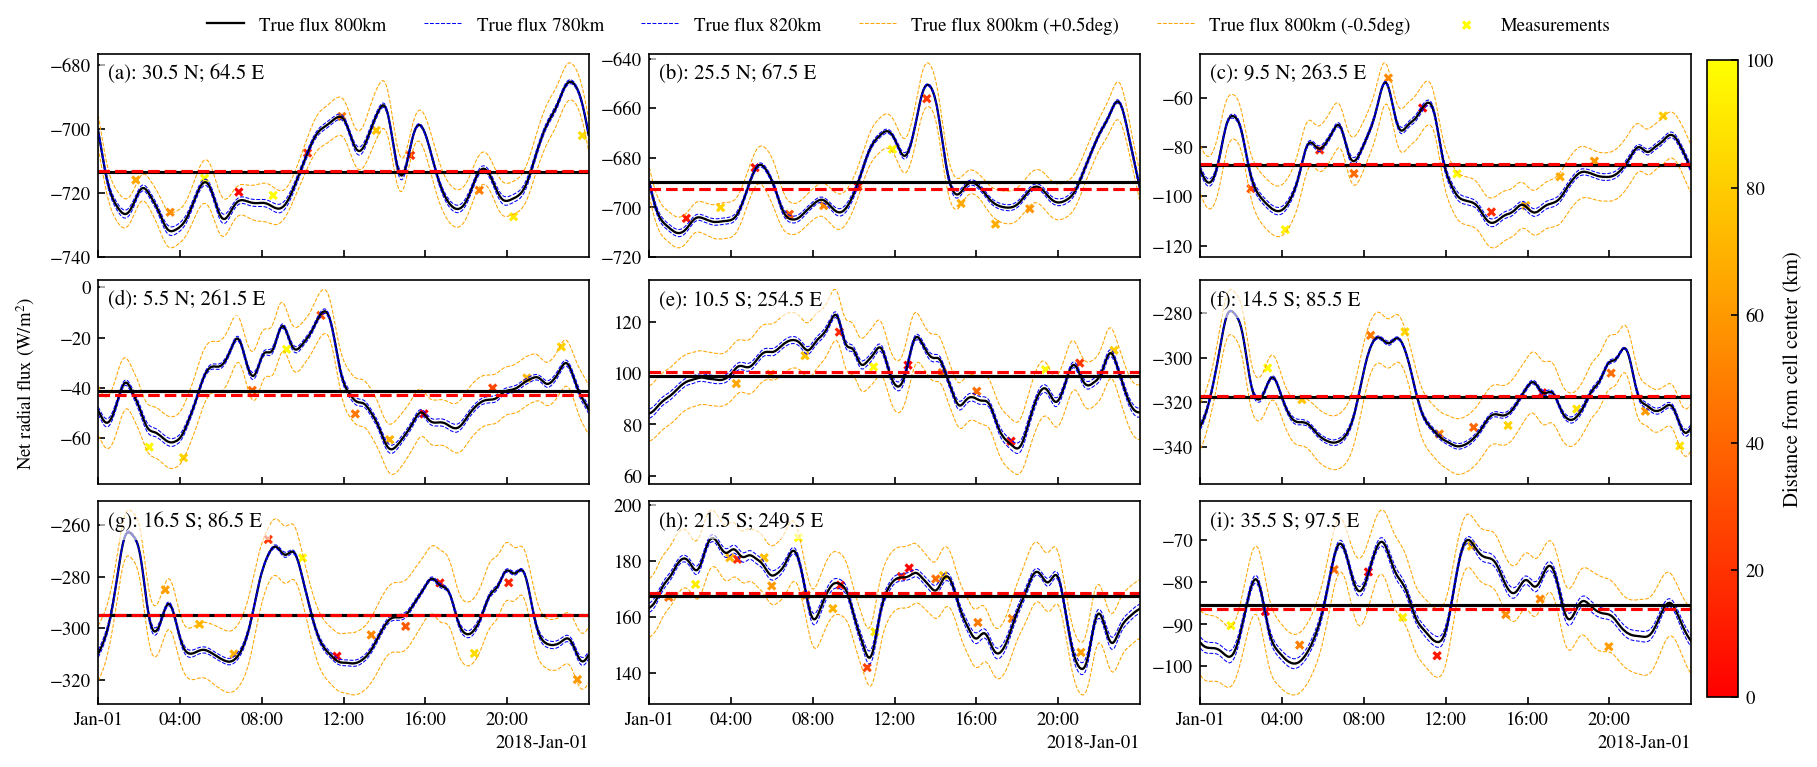

In [ ]:
# plot expected_vs_measured
n_lon_truth, n_lat_truth = 360, 180
EEI_name = check_EEI_consistency(input_names)

lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon_stacking, n_lat_stacking)
lon_step = np.mean(np.diff(lon_vec))
lat_step = np.mean(np.diff(lat_vec))
r_grid = lonlat_to_r(lon_vec, lat_vec, altitude, "spherical")

# EEI_full_window = radiation_settings_from_EEI_truth_name(EEI_name)['jd_interval']
# jd_0 = EEI_full_window[0]

frame_tag = '_SFF' if frame=='SFF' else ''

# load truth
day_jd_hist = get_EEI_truth_daily_jd_arrays(EEI_name)[day_idx]
day_jd_window = [day_jd_hist[0], day_jd_hist[-1]]

net_780km_daily_hist = load_map_file(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_'+str(n_lat_truth)+'x'+str(n_lon_truth), 
                                    'daily_hist_net_780km'+frame_tag), 'day_'+str(day_idx), n_lon_truth, n_lat_truth)

net_820km_daily_hist = load_map_file(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_'+str(n_lat_truth)+'x'+str(n_lon_truth), 
                                    'daily_hist_net_820km'+frame_tag), 'day_'+str(day_idx), n_lon_truth, n_lat_truth)

net_800km_daily_hist = load_map_file(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_'+str(n_lat_truth)+'x'+str(n_lon_truth), 
                                    'daily_hist_net_800km'+frame_tag), 'day_'+str(day_idx), n_lon_truth, n_lat_truth)


jd_hist_array = get_full_output_var_hist(input_names, 'jd_vec')
radial_flux_meas_3D_arrays = get_radial_measurement_arrays(input_names, n_lon_stacking, n_lat_stacking, frame, meas='flux', mode='3D')

if frame=="ECEF":
    r_hist_array = get_full_output_var_hist(input_names, 'xyz_ecef')
elif frame=="SFF":
    r_hist_array = get_full_output_var_hist(input_names, 'xyz_sun_frame')



all_n_meas_day = [None] * n_sat
all_3D_meas_arrays_day = [None] * n_sat
all_jd_arrays_day = [None] * n_sat
all_r_arrays_day = [None] * n_sat

for i in range(n_sat):
    first_last_idxs = get_jd_window_idxs(jd_hist_array[i], np.array([day_jd_window]))[0]
    meas_3D_array = radial_flux_meas_3D_arrays[i][:, :, first_last_idxs[0]:(first_last_idxs[1]+1)]
    
    all_3D_meas_arrays_day[i] = meas_3D_array.todense()
    all_n_meas_day[i] = getnnz(meas_3D_array, axis=2)
    all_jd_arrays_day[i] = jd_hist_array[i][first_last_idxs[0]:(first_last_idxs[1]+1)]
    all_r_arrays_day[i] = r_hist_array[i][first_last_idxs[0]:(first_last_idxs[1]+1), :]

total_n_meas_map = np.sum(all_n_meas_day, axis=0)
n_max = np.max(total_n_meas_map)
cell_idxs = np.where(total_n_meas_map > np.min([10, np.max(n_max-2)]))
#cell_idxs = [cell_idxs[0][0:10], cell_idxs[1][0:10]] # TODO: remove this line, just for testing

full_3D_meas_array = np.concatenate(all_3D_meas_arrays_day, axis=2)
full_jd_meas_array = np.concatenate(all_jd_arrays_day, axis=0)
full_r_array = np.concatenate(all_r_arrays_day, axis=0)

fig, axes = plt.subplots(3, 3, sharex=True, figsize=(12,5), layout="constrained")
axes = axes.flatten()   # easier indexing
norm = plt.Normalize(vmin=0, vmax=100)
n_plots = len(axes)

# randomly select n_plots from cell_idxs:
chosen_idxs = np.sort(np.random.choice(len(cell_idxs[0]), size=n_plots, replace=False))
cell_idxs = [cell_idxs[0][chosen_idxs], cell_idxs[1][chosen_idxs]]

for j, (lat_idx, lon_idx) in enumerate(zip(cell_idxs[0], cell_idxs[1])):

    lat_lon_pair = (lat_vec[lat_idx], lon_vec[lon_idx])
    #print("lat_idx: ", lat_idx, " lon_idx: ", lon_idx)
    cell_meas_hist = full_3D_meas_array[lat_idx, lon_idx, :]
    idxs = np.where(cell_meas_hist != 0)[0]

    cell_meas_hist = cell_meas_hist[idxs]
    cell_jd_meas_hist = full_jd_meas_array[idxs]

    cell_center_r = r_grid[lat_idx, lon_idx]
    sat_r_hist = full_r_array[idxs, :]
    cell_center_offsets = np.linalg.norm(sat_r_hist - cell_center_r[None,:], axis=1)

    # plot
    datetime_array = Plotter.jd_to_datetime(day_jd_hist)
    if correct_meas:
        cell_meas_hist = np.interp(cell_jd_meas_hist, day_jd_hist, net_800km_daily_hist[lat_idx, lon_idx, :])

    ax = axes[j]
    ax.plot(datetime_array, net_800km_daily_hist[lat_idx, lon_idx, :], label='True flux 800km', color='k', lw=1.1)
    if add_20km_bounds:
        ax.plot(datetime_array, net_780km_daily_hist[lat_idx, lon_idx, :], label='True flux 780km', color='b', lw=0.5, linestyle='--')
        ax.plot(datetime_array, net_820km_daily_hist[lat_idx, lon_idx, :], label='True flux 820km', color='b', lw=0.5, linestyle='--')
    
    if add_side_bounds:
        bound_1 = np.mean([net_800km_daily_hist[lat_idx, lon_idx, :], net_800km_daily_hist[lat_idx+1, lon_idx+1, :]], axis=0)
        ax.plot(datetime_array, bound_1, label='True flux 800km (+'+str(lon_step/2)+'deg)', color='orange', lw=0.5, linestyle='--')
        
        bound_2 = np.mean([net_800km_daily_hist[lat_idx, lon_idx, :], net_800km_daily_hist[lat_idx-1, lon_idx-1, :]], axis=0)
        ax.plot(datetime_array, bound_2, label='True flux 800km (-'+str(lon_step/2)+'deg)', color='orange', lw=0.5, linestyle='--')
    
    if add_offset_colors:
        ax.scatter(Plotter.jd_to_datetime(cell_jd_meas_hist), cell_meas_hist, label='Measurements', 
               c=norm(cell_center_offsets), cmap="autumn", marker='x', s=12)
    else:
        ax.scatter(Plotter.jd_to_datetime(cell_jd_meas_hist), cell_meas_hist, label='Measurements', 
                   c='red', marker='x', s=12)
        
    if add_avgs:
        ax.axhline(np.mean(net_800km_daily_hist[lat_idx, lon_idx, :]), color='k')
        ax.axhline(np.mean(cell_meas_hist), color='r', linestyle='--')
    
    # errors = net_800km_daily_hist[lat_idx, lon_idx, idxs] - cell_meas_hist

    locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.set_xlim(datetime_array[0], datetime_array[-1])

    ax.text(
        0.02, 0.95,
        f"({letters[j]}): {latlon_to_coord_name(lat_lon_pair)}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )


fig.supylabel('Net radial flux (W/m$^2$)', fontsize=9)

if add_offset_colors:
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="autumn"), ax=axes, orientation='vertical', 
                label='Distance from cell center (km)', fraction=0.02, pad=0.01)

# Collect all handles and labels from all axes to avoid duplicates
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create a single legend for the entire figure
# Use unique handles and labels for a clean legend
unique_labels = dict(zip(labels, handles))
fig.suptitle('  ')
# set n_cols to the number of curves in ax:

fig.legend(unique_labels.values(), unique_labels.keys(), loc='upper center', ncols=len(ax.lines)) # bbox_to_anchor=(1, 1)

#fig.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the legend


#fig.legend([curve_800, curve_780, scatter_meas], bbox_to_anchor=(0.5,1.02))


(np.float64(17532.0), np.float64(17532.999305495996))

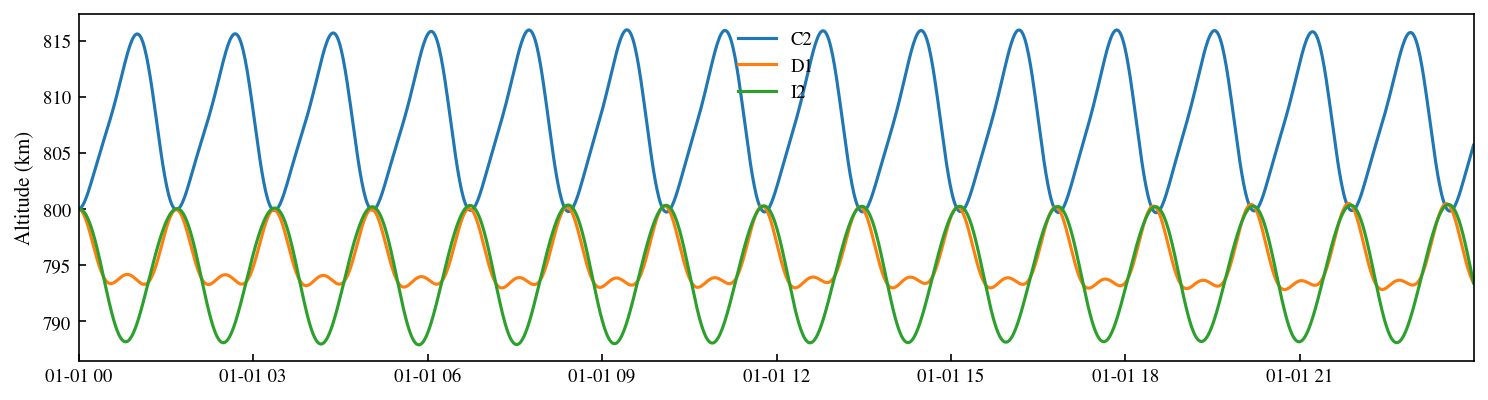

In [36]:
hlatlon_hist_array = get_full_output_var_hist(input_names, 'h_lat_lon'+frame_tag)

fig_alt, ax_alt = plt.subplots(figsize=(12,3))
for i in range(n_sat):
    jd_array = jd_hist_array[i]
    idxs = get_jd_window_idxs(jd_array, np.array([day_jd_window]))[0]
    ax_alt.plot(Plotter.jd_to_datetime(jd_array[idxs[0]:idxs[1]+1]), hlatlon_hist_array[i][idxs[0]:idxs[1]+1,0], label=sat_names[i])
ax_alt.set_ylabel('Altitude (km)')
ax_alt.legend()
ax_alt.set_xlim(Plotter.jd_to_datetime(day_jd_window[0]), Plotter.jd_to_datetime(day_jd_window[1]))